In [1]:
import cv2
import matplotlib.pyplot as plt

In [2]:
# =========================
# CONFIG
# =========================

IMAGE_PATH = "C:\\stock_control_deep_learning\\runs\\detect\\predict7\\IMG-20250318-WA0233_jpg.rf.04c94b1e318ec299b6f920300f98701e.jpg"

# Formato YOLO:
# class_id, x_center, y_center, width, height
#
# Valores NORMALIZADOS entre 0 e 1

labels = [
    [1, 0.49, 0.36, 0.33, 0.12],
    [0, 0.50, 0.39, 0.04, 0.03],

    [0, 0.18, 0.16, 0.05, 0.09],
    [0, 0.24, 0.16, 0.05, 0.09],
    [0, 0.30, 0.16, 0.05, 0.09],

    [1, 0.77, 0.34, 0.12, 0.07],
]

In [3]:
# =========================
# LOAD IMAGE
# =========================

image = cv2.imread(IMAGE_PATH)

if image is None:
    raise Exception(f"Não foi possível abrir a imagem: {IMAGE_PATH}")

image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

img_h, img_w = image.shape[:2]

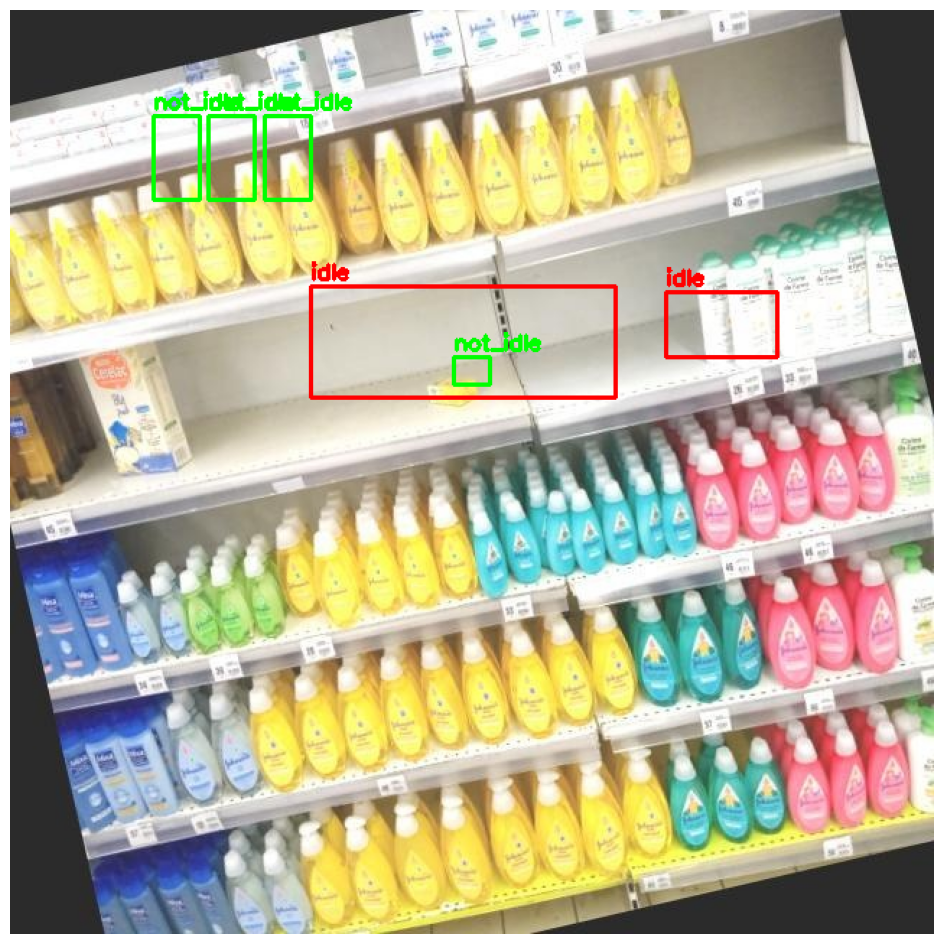

In [4]:
# =========================
# DRAW BOXES
# =========================

for label in labels:

    class_id, x_center, y_center, width, height = label

    # YOLO -> pixel coords
    x_center_px = x_center * img_w
    y_center_px = y_center * img_h

    width_px = width * img_w
    height_px = height * img_h

    x1 = int(x_center_px - width_px / 2)
    y1 = int(y_center_px - height_px / 2)

    x2 = int(x_center_px + width_px / 2)
    y2 = int(y_center_px + height_px / 2)

    # Cores
    # idle = vermelho
    # not_idle = verde
    if class_id == 1:
        color = (255, 0, 0)
        text = "idle"
    else:
        color = (0, 255, 0)
        text = "not_idle"

    # Draw rectangle
    cv2.rectangle(image, (x1, y1), (x2, y2), color, 2)

    # Label
    cv2.putText(
        image,
        text,
        (x1, y1 - 5),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.5,
        color,
        2
    )


# =========================
# SHOW IMAGE
# =========================

plt.figure(figsize=(12, 12))
plt.imshow(image)
plt.axis("off")
plt.show()